# Laboratório 06: Tratamento de Dados Raros e Alta Cardinalidade

**Disciplina:** Extração e Preparação de Dados (IBM8915)  
**Professor:** Luís Aramis

---

## 🎯 Objetivo

Compreender o impacto negativo da **alta cardinalidade** (o fenômeno da _cauda longa_) no desempenho de modelos analíticos. Você aprenderá a:

1. **Diagnosticar** a distribuição de frequência de variáveis categóricas.
2. **Decidir** um limiar de corte adequado ao contexto de negócio.
3. **Aplicar** técnicas do Pandas para agrupar categorias raras.

---

### 🗺️ Roteiro da Aula

| Parte | Tipo | Tempo estimado |
|---|---|---|
| **Parte 1** | Exemplo Guiado (Descoberta) | ~10 min |
| **Parte 2** | Exercício Prático | ~10 min |
| **Parte 3** | Desafio para Casa (Pipeline Completo) | ~30 min |

In [1]:
# Setup inicial — execute esta célula antes de tudo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


---

## Parte 1: Exemplo Guiado — O Problema da Cauda Longa

Variáveis categóricas como `Cidade`, `Profissão` ou `Marca` costumam ter um comportamento típico: **poucos valores dominam** e **muitos valores aparecem raramente** (a chamada *cauda longa*).

Se treinarmos um modelo de Machine Learning com esses dados raros, ele irá **memorizar ruído** (overfitting) em vez de aprender padrões reais. A solução é o **Binning Categórico**: agrupar tudo que for raro na categoria `'Outros'`.

---

### 🔎 Passo 1 — Explore antes de rodar

Abaixo, criamos um dataset de 1.000 clientes com a coluna `Cidade`. Antes de executar qualquer célula, responda:

> **📝 Quantas cidades únicas você espera encontrar? Quais cidades acha que irão dominar os dados?**
>
> _Sua hipótese: [escreva aqui]_

Agora execute a célula abaixo e veja o dataset.

In [2]:
# Criando o dataset de cidades com alta cardinalidade
np.random.seed(42)
cidades_comuns = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte']
cidades_raras  = ['Cabo Frio', 'Itu', 'Bauru', 'Gramado', 'Ouro Preto', 'Ilhéus', 'Picos']

amostra_cidades = np.random.choice(cidades_comuns, 950, p=[0.6, 0.3, 0.1]).tolist()
amostra_cidades.extend(np.random.choice(cidades_raras, 50))

df_exemplo = pd.DataFrame({'ID_Cliente': range(1, 1001), 'Cidade': amostra_cidades})

print(f"Total de linhas: {len(df_exemplo)}")
print(f"Cidades únicas: {df_exemplo['Cidade'].nunique()}")
df_exemplo.head()

Total de linhas: 1000
Cidades únicas: 10


,ID_Cliente,Cidade
0,1,São Paulo
1,2,Belo Horizonte
2,3,Rio de Janeiro
3,4,São Paulo
4,5,São Paulo


### 🔎 Passo 2 — Visualize a distribuição

A forma mais rápida de enxergar a *cauda longa* é com um gráfico de barras. Execute e observe:

> **📝 O gráfico evidenciou o que você esperava na sua hipótese? O que você percebe sobre a diferença de proporção entre as cidades comuns e raras?**
>
> _Sua resposta: [escreva aqui]_

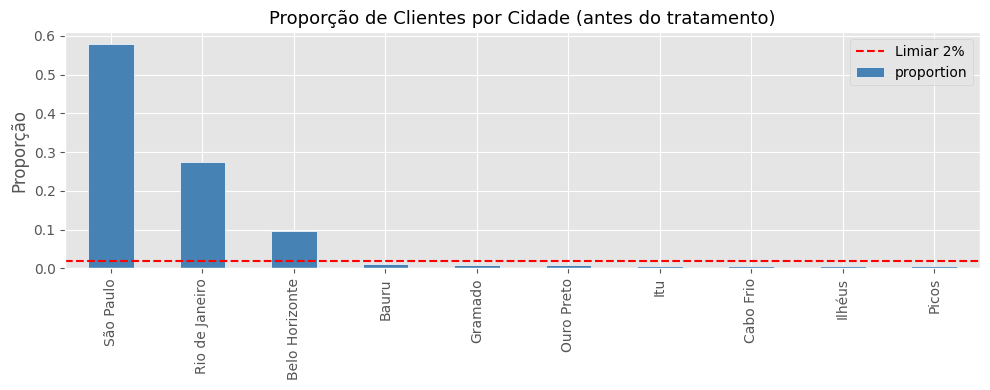


--- Proporção Original ---
Cidade
São Paulo         0.580
Rio de Janeiro    0.274
Belo Horizonte    0.096
Bauru             0.010
Gramado           0.008
Ouro Preto        0.008
Itu               0.007
Cabo Frio         0.006
Ilhéus            0.006
Picos             0.005


In [3]:
frequencias = df_exemplo['Cidade'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(10, 4))
frequencias.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(0.02, color='red', linestyle='--', linewidth=1.5, label='Limiar 2%')
ax.set_title('Proporção de Clientes por Cidade (antes do tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Proporção Original ---")
print(frequencias.to_string())

### 🔎 Passo 3 — Aplique a transformação

A linha vermelha tracejada no gráfico representa nosso **limiar de negócio**: qualquer cidade que aparecer em menos de 2% da base será agrupada como `'Outros'`. Execute e compare com o gráfico anterior.

Cidades que serão agrupadas em 'Outros': [np.str_('Bauru'), np.str_('Gramado'), np.str_('Ouro Preto'), np.str_('Itu'), np.str_('Cabo Frio'), np.str_('Ilhéus'), np.str_('Picos')]


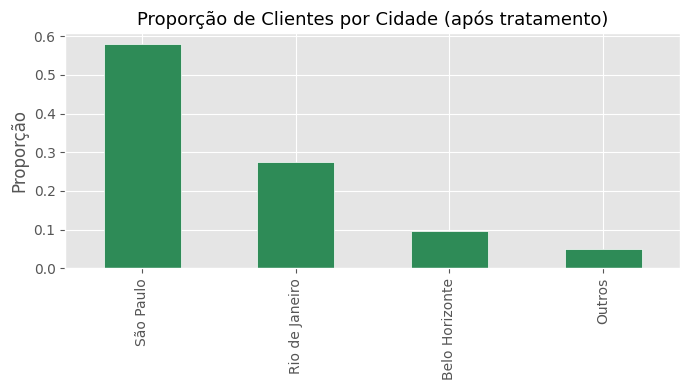


--- Proporção Após Tratamento ---
Cidade
São Paulo         0.580
Rio de Janeiro    0.274
Belo Horizonte    0.096
Outros            0.050


In [4]:
# Definindo o limiar
limite = 0.02
cidades_para_agrupar = frequencias[frequencias < limite].index

print(f"Cidades que serão agrupadas em 'Outros': {list(cidades_para_agrupar)}")

# Aplicando a transformação com .loc e .isin()
df_exemplo.loc[df_exemplo['Cidade'].isin(cidades_para_agrupar), 'Cidade'] = 'Outros'

# Visualização após tratamento
freq_apos = df_exemplo['Cidade'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(7, 4))
freq_apos.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Proporção de Clientes por Cidade (após tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print("\n--- Proporção Após Tratamento ---")
print(freq_apos.to_string())

### 💬 Reflexão — Parte 1

> **O que aconteceria com um modelo de ML se você tivesse treinado com as 10 cidades originais em vez das 4 categorias limpas?**  
> Pense especificamente em: *quantidade de colunas geradas pelo One-Hot Encoding* e *frequência de cada categoria no treino vs. teste*.
>
> _Sua resposta: [escreva aqui]_

---

## Parte 2: Exercício Prático — Mão na Massa

Você extraiu um banco de dados de currículos. A coluna `Profissao` foi preenchida **manualmente** pelos usuários, gerando variações e erros típicos de dados do mundo real.

**Contexto:** O time de RH quer usar esses dados para treinar um modelo de triagem. Mas com tantas variações raras, o modelo irá decorar profissões que aparecem 1 ou 2 vezes, sem poder generalizá-las.

---

### 📝 Formule sua hipótese antes de começar

> Com um limiar de **3% (0.03)**, quantas profissões você acha que sobrarão após o tratamento? (Considere que há 3 profissões comuns e 8 raras)
>
> _Minha estimativa: [escreva aqui] — Justificativa: [escreva aqui]_

Execute a célula abaixo para gerar os dados e depois escreva sua solução.

In [5]:
# NÃO ALTERE ESTE CÓDIGO - Geração da base de currículos (RH)
np.random.seed(42)
profissoes_comuns = ['Analista', 'Desenvolvedor', 'Gerente']
profissoes_raras  = ['Eng. de Dados', 'Cientista de Dados', 'Estagiário', 'Arquiteto',
                     'Recrutador', 'Designer', 'DBA', 'Scrum Master']
amostra_prof = np.random.choice(profissoes_comuns, 970, p=[0.4, 0.4, 0.2]).tolist()
amostra_prof.extend(np.random.choice(profissoes_raras, 30))
df_rh = pd.DataFrame({'ID_Candidato': range(1, 1001), 'Profissao': amostra_prof})
print(f"Total de candidatos: {len(df_rh)}")
print(f"Profissões únicas: {df_rh['Profissao'].nunique()}")
df_rh['Profissao'].value_counts()


Total de candidatos: 1000
Profissões únicas: 11


Profissao
Analista              409
Desenvolvedor         366
Gerente               195
Eng. de Dados           7
Estagiário              5
Cientista de Dados      4
Scrum Master            3
Designer                3
Recrutador              3
Arquiteto               3
DBA                     2
Name: count, dtype: int64

In [6]:
# RESOLUÇÃO
# Passo 1: frequências relativas
freq_profissoes = df_rh['Profissao'].value_counts(normalize=True)

# Passo 2: profissões com frequência < 0.03
profissoes_para_agrupar = freq_profissoes[freq_profissoes < 0.03].index

# Passo 3: substituir as raras por 'Outros'
df_rh.loc[df_rh['Profissao'].isin(profissoes_para_agrupar), 'Profissao'] = 'Outros'

# Passo 4: contagem final
print(df_rh['Profissao'].value_counts())


Profissao
Analista         409
Desenvolvedor    366
Gerente          195
Outros            30
Name: count, dtype: int64


In [7]:
# ✅ CÉLULA DE VERIFICAÇÃO — Execute após completar o exercício
try:
    n_categorias = df_rh['Profissao'].nunique()
    assert n_categorias <= 4, (
        f"❌ Ainda há {n_categorias} categorias únicas. "
        "Verifique se o limiar de 0.03 foi aplicado corretamente."
    )
    assert 'Outros' in df_rh['Profissao'].values, (
        "❌ A categoria 'Outros' não foi encontrada. "
        "Certifique-se de usar exatamente a string 'Outros'."
    )
    print(f"✅ Parabéns! Cardinalidade reduzida para {n_categorias} categorias.")
    print("   O DataFrame df_rh está pronto para o One-Hot Encoding do Lab 07!")
except AssertionError as e:
    print(e)

✅ Parabéns! Cardinalidade reduzida para 4 categorias.
   O DataFrame df_rh está pronto para o One-Hot Encoding do Lab 07!


### 💬 Reflexão — Parte 2

> 1. Sua hipótese estava correta? Se não, o que te surpreendeu?
> 2. **Questão de negócio:** Ao agrupar `'Eng. de Dados'` junto com `'Estagiário'` em `'Outros'`, você cometeu algum erro analítico? Como poderia mitigar isso?
>
> _Suas respostas: [escreva aqui]_

---

## Parte 3: Desafio para Casa — O Pipeline Completo

Este desafio consolida tudo das **Aulas 02 a 08**.  
Você irá trabalhar com um CSV sujo chamado `rais_amostra_suja.csv`, simulando a base pública da **Relação Anual de Informações Sociais (RAIS)** do Brasil.

---

### ⚠️ Importante: desta vez, o limiar é sua decisão!

Ao contrário dos exemplos anteriores, **não há um limiar definido** para a etapa 4.  
Você deve **explorar a distribuição** da coluna `Municipio` e **justificar analiticamente** o corte que escolher.

**A Missão:**

1. **(Aula 02):** Carregue o CSV com `sep=';'` e `encoding='latin-1'`.
2. **(Aula 05):** Audite e remova as linhas duplicadas.
3. **(Aula 07):** Preencha os nulos da coluna `Salario` com a Mediana.
4. **(Aula 08 — Decisão sua!):** Explore a distribuição de `Municipio`, escolha um limiar, justifique e aplique o agrupamento.
5. **(Aula 04):** Use `groupby` para calcular a **Média Salarial por Município** após a limpeza.

_O DataFrame limpo estará pronto para o One-Hot Encoding que faremos no `lab_07`!_ 🚀

In [8]:
df = pd.read_csv('../data/rais_amostra_suja.csv', sep=';', encoding='latin-1')
df.drop_duplicates(inplace=True)
df['Salario'].fillna(df['Salario'].median(), inplace=True)
print(f'Shape final: {df.shape}')


Shape final: (1000, 3)


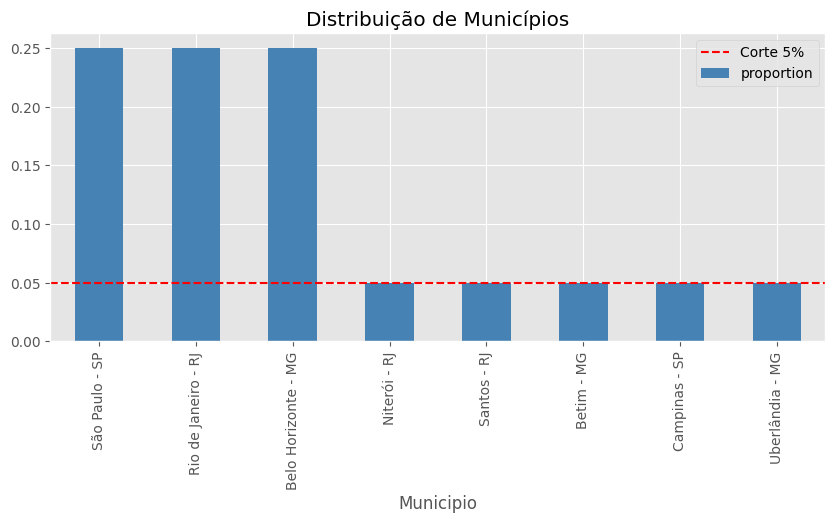

In [9]:
freq_municipios = df['Municipio'].value_counts(normalize=True)
plt.figure(figsize=(10,4))
freq_municipios.plot(kind='bar', color='steelblue')
plt.axhline(y=0.05, color='red', linestyle='--', label='Corte 5%')
plt.title('Distribuição de Municípios')
plt.legend()
plt.show()


In [10]:
meu_limiar = 0.05
municipios_para_agrupar = freq_municipios[freq_municipios < meu_limiar].index
df.loc[df['Municipio'].isin(municipios_para_agrupar), 'Municipio'] = 'Outros'
print(f'Municípios após tratamento: {df["Municipio"].nunique()}')


Municípios após tratamento: 8


### 📝 Justificativa do Limiar (obrigatório)

> Com base no gráfico acima, defina o limiar que você vai usar e justifique:
>
> **Limiar escolhido:** [ex: 10%]
>
> **Justificativa:** [Por que este corte faz sentido analítico para esta base?  
> Quais municípios ficam de fora e isso é aceitável?]

In [11]:
# RESOLUÇÃO - aplica a redução com o limiar justificado
meu_limiar = 0.05
freq_municipios = df['Municipio'].value_counts(normalize=True)
municipios_para_agrupar = freq_municipios[freq_municipios < meu_limiar].index
df.loc[df['Municipio'].isin(municipios_para_agrupar), 'Municipio'] = 'Outros'

print(f"Municípios únicos antes: {freq_municipios.shape[0]}")
print(f"Municípios únicos depois: {df['Municipio'].nunique()}")


Municípios únicos antes: 8
Municípios únicos depois: 8


In [12]:
# RESOLUÇÃO - Média Salarial por Município (limpo)
media_municipio = df.groupby('Municipio')['Salario'].mean().sort_values(ascending=False)
print("Média Salarial por Município:")
print(media_municipio.round(2))


Média Salarial por Município:
Municipio
Betim - MG             3643.24
Rio de Janeiro - RJ    3536.76
Campinas - SP          3529.18
Santos - RJ            3512.49
Belo Horizonte - MG    3486.20
Niterói - RJ           3447.72
São Paulo - SP         3402.37
Uberlândia - MG        3394.84
Name: Salario, dtype: float64


### 💬 Reflexão Final

> 1. O município `'Outros'` ficou com salário médio acima ou abaixo dos municípios individuais? O que isso pode significar?
> 2. Se você fosse apresentar este resultado para um gestor de RH, o que você **não** poderia afirmar com base apenas nesta análise?
> 3. O que aconteceria na prática se você rodasse `pd.get_dummies()` sobre `Municipio` **sem** ter feito a redução de cardinalidade?
>
> _Suas respostas: [escreva aqui]_

---

**🎓 Parabéns por concluir o Lab 06!**  
No próximo laboratório (`lab_07_encoders.ipynb`), aplicaremos `pd.get_dummies()` sobre este DataFrame já limpo. Você verá exatamente por que o pré-processamento de hoje era indispensável.